In [11]:
import scanpy as sc
import numpy as np

In [3]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_new_cytokine_processed.h5ad")

In [4]:
adata.X = adata.layers["counts"]
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [7]:
adata.obs.head()

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,condition,is_control
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,...,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive,Donor10_4-1BBL,False
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,...,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive,Donor10_4-1BBL,False
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,...,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory,Donor10_4-1BBL,False
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,...,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono,Donor10_4-1BBL,False
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,...,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono,Donor10_4-1BBL,False


donors = adata.obs["donor"].unique()
perturbations = ["FasL", "IFN-omega", "IL-1Ra","OX40L", "CD27L", "IL-32-beta", "M-CSF", "BAFF", "IFN-gamma", "ADSF"]

In [175]:
means = []
for donor in donors:
    adata_donor = adata[adata.obs["donor"]==donor]
    means.append(adata_donor[adata_donor.obs["cytokine"]=="PBS"].X.mean(axis=0))


In [176]:
means = np.array(means).squeeze()

In [177]:
above = (means>0.1)
genes_to_include_mask = (above.sum(axis=0) == 12)

In [178]:
genes_to_include_mask.sum()

560

In [179]:
logfoldchanges = {}
for donor in donors:
    logfoldchanges[donor] = {}
    adata_donor = adata[adata.obs["donor"]==donor, genes_to_include_mask]
    ctrl = adata_donor[adata_donor.obs["cytokine"]=="PBS"].X.mean(axis=0).squeeze()
    for pert in perturbations:
        perturbed = adata_donor[adata_donor.obs["cytokine"]==pert].X.mean(axis=0).squeeze()
        logfoldchanges[donor][pert] = np.log2(perturbed/ctrl)

In [180]:
vars_pert = {}
for pert in perturbations:
    vars_pert[pert] = np.var(np.array([logfoldchanges[d][pert] for d in donors]).squeeze(), axis=0)

In [181]:
{k: (np.max(v), np.argmax(v)) for k,v in vars_pert.items()}

{'FasL': (0.15382539, 174),
 'IFN-omega': (1.6313933, 118),
 'IL-1Ra': (1.0385001, 414),
 'OX40L': (0.1844318, 118),
 'CD27L': (0.34216046, 117),
 'IL-32-beta': (1.2895783, 117),
 'M-CSF': (0.37115908, 66),
 'BAFF': (0.32091343, 117),
 'IFN-gamma': (1.2952856, 117),
 'ADSF': (0.24343783, 547)}

In [228]:
ifn_omega_var = vars_pert["M-CSF"]

In [229]:
top_k = 50
indices = np.argpartition(ifn_omega_var , -top_k)[-top_k:]

In [230]:
mask = np.zeros_like(ifn_omega_var , dtype=bool)
mask[indices] = True

In [231]:
adata[:,genes_to_include_mask][:,mask].var_names

Index(['VCAN', 'RASAL2', 'SLC1A3', 'FCN1', 'NRP1', 'LGMN', 'MMP9', 'RUBCNL',
       'ACP5', 'STEAP1B', 'MS4A6A', 'NRP2', 'IFIT3', 'IFIT2', 'TGFBI', 'EEPD1',
       'STARD13', 'ADAMDEC1', 'RSAD2', 'CTSL', 'CD36', 'GPNMB', 'ENPP2',
       'SLCO2B1', 'SLCO5A1', 'THBS1', 'SLC39A8', 'S100A8', 'PDGFC', 'CRIM1',
       'SLC7A11', 'FRMD4A', 'TMEM163', 'DAB2', 'PID1', 'FMNL2', 'NEXN',
       'S100A9', 'SPRED1', 'P2RY14', 'LDLRAD3', 'CHST15', 'TPRG1', 'SULF2',
       'LPAR1', '7SK', 'MAFB', 'ITSN1', 'LINC00937', 'MSC-AS1'],
      dtype='object')

In [223]:
mask.shape

(560,)

In [183]:
ifn_beta = {donor: logfoldchanges[donor]["IFN-omega"][:,117] for donor in donors}

In [184]:
ifn_beta

{'Donor10': matrix([[0.06299705]], dtype=float32),
 'Donor11': matrix([[1.4806553]], dtype=float32),
 'Donor12': matrix([[1.9350678]], dtype=float32),
 'Donor1': matrix([[0.14268717]], dtype=float32),
 'Donor2': matrix([[1.6226354]], dtype=float32),
 'Donor3': matrix([[-0.0243062]], dtype=float32),
 'Donor4': matrix([[0.07322158]], dtype=float32),
 'Donor5': matrix([[2.536343]], dtype=float32),
 'Donor6': matrix([[0.91803956]], dtype=float32),
 'Donor7': matrix([[3.5876787]], dtype=float32),
 'Donor8': matrix([[1.6699265]], dtype=float32),
 'Donor9': matrix([[3.7780821]], dtype=float32)}

In [185]:
adata.var_names[genes_to_include_mask][118]

'IFIT2'

In [186]:
bdata = adata[adata.obs["cytokine"].isin(("PBS", "IFN-omega"))]

In [187]:
sc.pp.subsample(bdata, n_obs=50000)

In [188]:
sc.pp.pca(bdata)
sc.pp.neighbors(bdata)
sc.tl.umap(bdata)

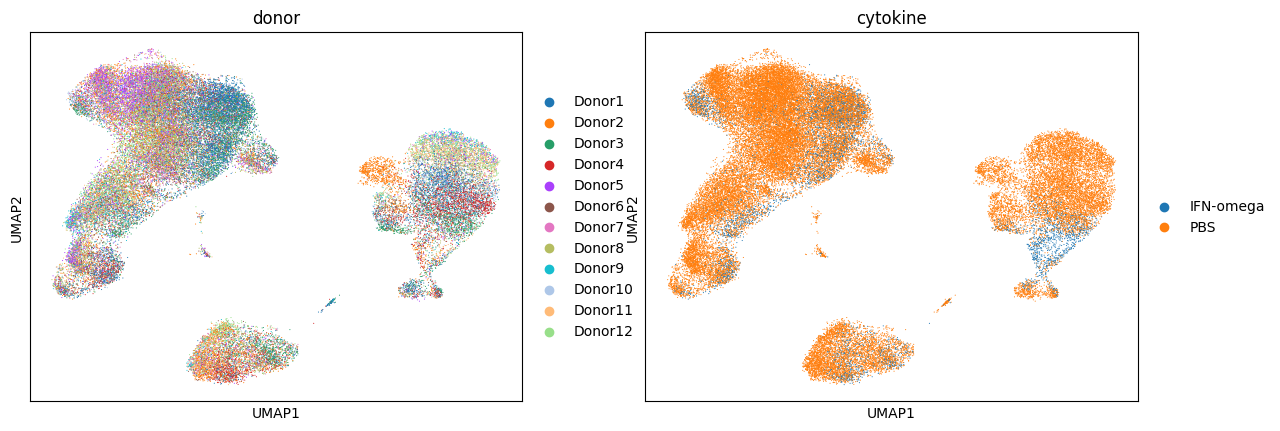

In [189]:
sc.pl.umap(bdata, color=["donor", "cytokine"])

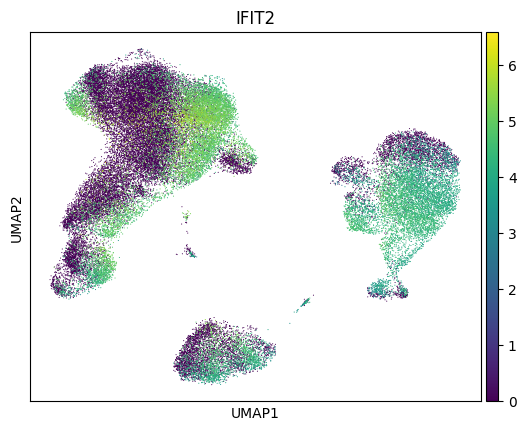

In [190]:
sc.pl.umap(bdata, color = 'IFIT2')

In [191]:
for d in donors:
    for cyto in bdata.obs["cytokine"].unique():
        bdata.obs[f"IFIT2_{d}_{cyto}"] = (bdata.obs["cytokine"]==cyto) * (bdata.obs["donor"]==d) * bdata[:, "IFIT2"].X.toarray().squeeze()

In [193]:
bdata.obs.head()

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,IFIT2_Donor5_PBS,IFIT2_Donor5_IFN-omega,IFIT2_Donor6_PBS,IFIT2_Donor6_IFN-omega,IFIT2_Donor7_PBS,IFIT2_Donor7_IFN-omega,IFIT2_Donor8_PBS,IFIT2_Donor8_IFN-omega,IFIT2_Donor9_PBS,IFIT2_Donor9_IFN-omega
91_167_035__s75,Donor12_PBS,hg38,1071,1491,3049,91,167,35,H7,p2.F11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93_124_017__s14,Donor8_PBS,hg38,1801,3295,6876,93,124,17,H9,p2.C4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91_142_127__s80,Donor11_PBS,hg38,2243,4379,9702,91,142,127,H7,p2.D10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
94_017_131__s103,Donor3_PBS,hg38,2126,5369,11822,94,17,131,H10,B5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36_144_128__s66,Donor12_IFN-omega,hg38,2169,4532,7971,36,144,128,C12,p2.D12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


KeyError: 'Could not find key IFIT2_Donor10 in .var_names or .obs.columns.'

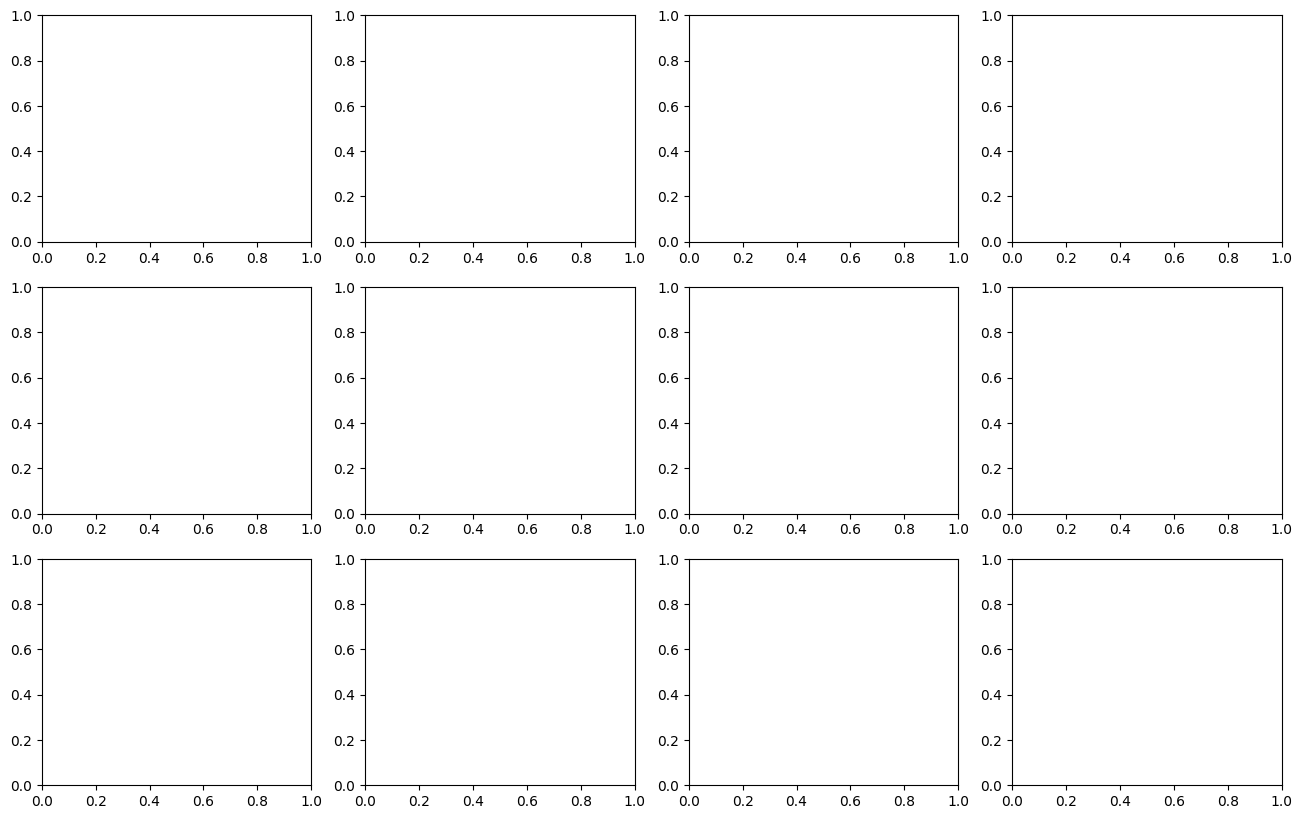

In [192]:
import matplotlib.pyplot as plt
import scanpy as sc
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop over donors and plot
for i, d in enumerate(donors):
    ax = axes[i]
    sc.pl.umap(
        bdata,
        color=f"IFIT2_{d}",
        ax=ax,
        show=False,
        title=f"IFIT2_{d}",
        frameon=False
    )


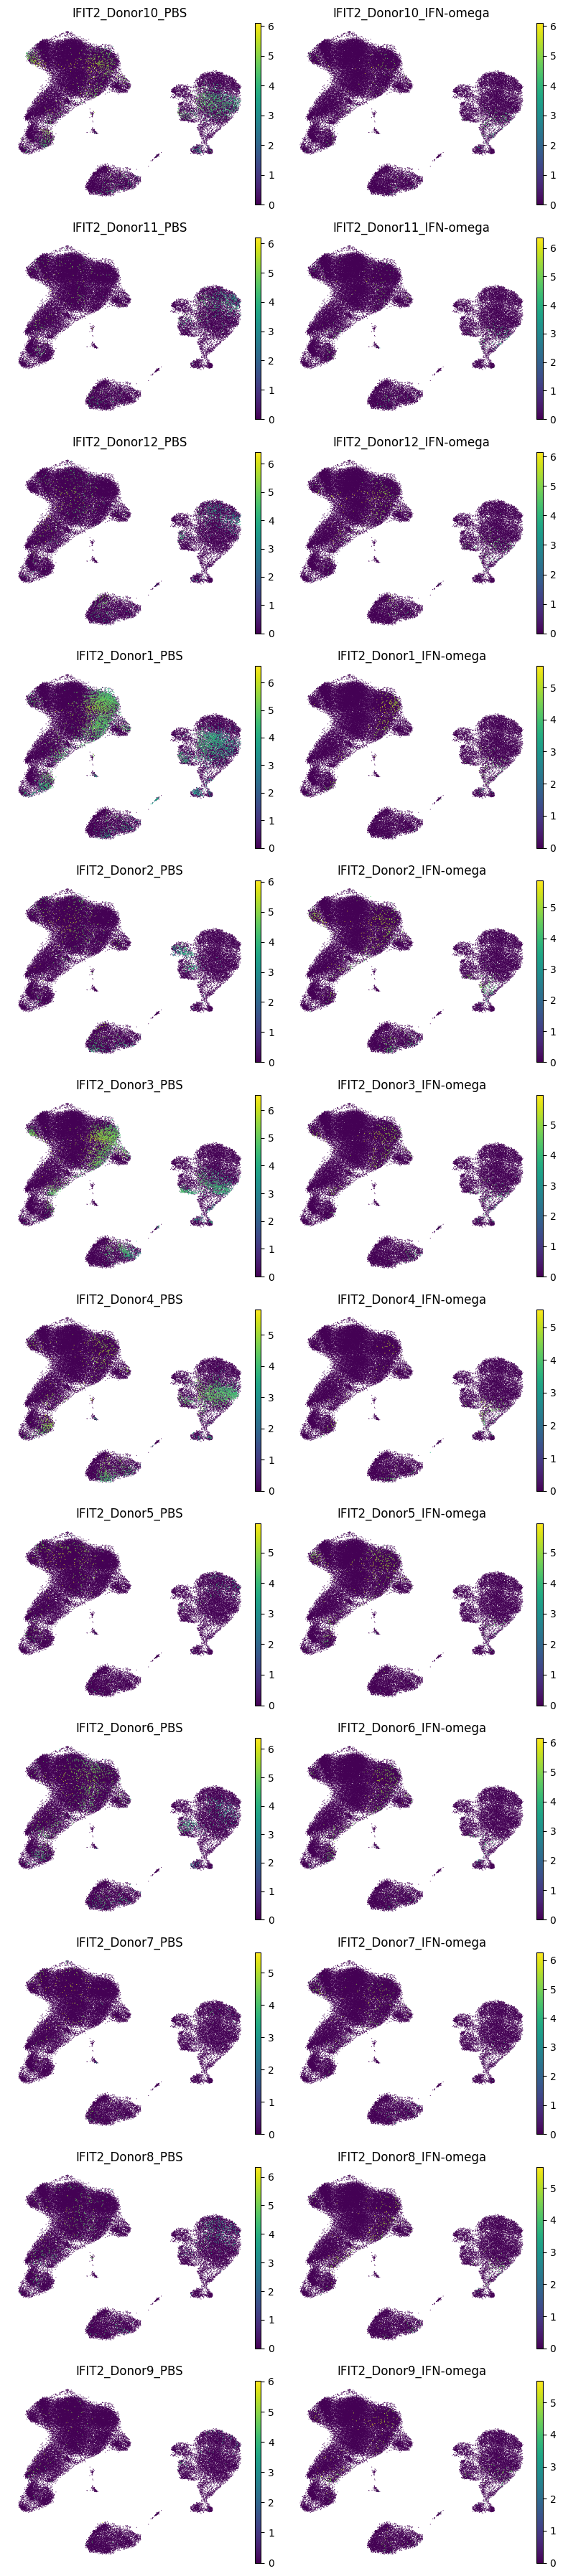

In [194]:
import matplotlib.pyplot as plt
import scanpy as sc

n_rows = len(donors)
n_cols = 2
random_order = np.arange(bdata.n_obs)
np.random.shuffle(random_order)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.reshape(n_rows, n_cols)

for i, d in enumerate(donors):
    for j, cyto in enumerate(["PBS", "IFN-omega"]):
        ax = axes[i, j]
        key = f"IFIT2_{d}_{cyto}"
        sc.pl.umap(
            bdata[random_order],
            color=key,
            ax=ax,
            show=False,
            title=key,
            frameon=False
        )

plt.tight_layout()
plt.show()
